In [1]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = {
    'cust_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'credit_score': [720, 690, 710, 680, 730, 440, 340, 340, 380, 400],
    '_Income': [50000, 60000, 55000, 52000, 58000, 6200, 4800, 4900, 6100, 5300],
    'Status':[1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

df.head(2)

,cust_id,credit_score,_Income,Status
0,1,720,50000,1
1,2,690,60000,1


In [4]:
X = df[['credit_score', '_Income']]
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

In [6]:


knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train) # this is where the model learns but in KNN it just stores the data
y_pred = knn.predict(X_test)    


In [7]:
X_test_copy = X_test.copy()
X_test_copy['Predicted_Status'] = y_pred
X_test_copy['Actual_Status'] = y_test.values
X_test_copy.head()

,credit_score,_Income,Predicted_Status,Actual_Status
8,380,6100,0,0


In [11]:
# As a assignment: try to implement KNN from scratch without using sklearn

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x in X.values:
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train.values]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train.iloc[i] for i in k_indices]
            predictions.append(np.bincount(k_nearest_labels).argmax())
        return np.array(predictions)
    

knn_scratch = KNN(k=2)
knn_scratch.fit(X_train, y_train)
y_pred_scratch = knn_scratch.predict(X_test)
y_pred_scratch

array([0])

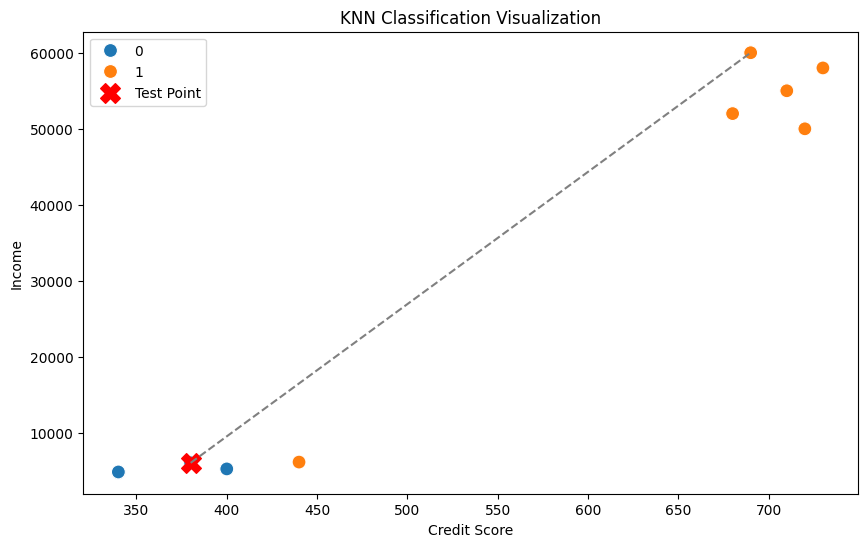

In [10]:
# lets visualize the data points and their classifications # also show distances
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='credit_score', y='_Income', hue='Status', s=100)
plt.scatter(X_test['credit_score'], X_test['_Income'], color='red', marker='X', s=200, label='Test Point')

# Show distances
for i in range(len(X_test)):
    plt.plot([X_test['credit_score'].iloc[i], X_train['credit_score'].iloc[y_pred_scratch[i]]],
             [X_test['_Income'].iloc[i], X_train['_Income'].iloc[y_pred_scratch[i]]], color='gray', linestyle='--')

plt.title('KNN Classification Visualization')
plt.xlabel('Credit Score')
plt.ylabel('Income')
plt.legend()
plt.show()


### Reference
- https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4